## Tratamento de Dados


In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Bibliotecas de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Define o caminho do arquivo CSV que será utilizado
caminho_arquivo_inicial = '/content/drive/MyDrive/avaliacoes.csv'

# Lê o arquivo CSV e armazena os dados em um DataFrame do pandas
df = pd.read_csv(caminho_arquivo_inicial)

# Cria uma variável para trabalhar com os dados
# (neste caso, df_limpo_tratar aponta para o mesmo DataFrame de df)
df_limpo_tratar = df

# Verifica quais valores da coluna "review_score" estão ausentes (NaN)
# O método isna() retorna True para valores ausentes e False para valores preenchidos
# O value_counts() conta quantos True e quantos False existem
df_limpo_tratar["review_score"].isna().value_counts()

Mounted at /content/drive


,count
review_score,
False,99224


## Tipagem dos dados

In [2]:
import pandas as pd

# cria uma cópia do DataFrame original para preservar o df sem alterações
df_limpo_tratar = df.copy()

# define o tipo das colunas de identificação, nota e comentários
df_limpo_tratar = df_limpo_tratar.astype({
    "review_id": "string",               # id da avaliação como texto
    "order_id": "string",                # id do pedido como texto
    "review_score": "int8",             # nota da avaliação como número inteiro
    "review_comment_title": "string",    # título do comentário como texto
    "review_comment_message": "string"   # mensagem do comentário como texto
})

# converte a coluna de data de criação para formato de data
# errors="coerce" transforma valores inválidos em NaT
df_limpo_tratar["review_creation_date"] = pd.to_datetime(
    df_limpo_tratar["review_creation_date"],
    errors="coerce"
)

# converte a coluna de resposta para formato de data e hora
# errors="coerce" evita erro em valores inválidos
df_limpo_tratar["review_answer_timestamp"] = pd.to_datetime(
    df_limpo_tratar["review_answer_timestamp"],
    errors="coerce"
)

# mostra no terminal os tipos finais de cada coluna
print(df_limpo_tratar.dtypes)

review_id                  string[python]
order_id                   string[python]
review_score                         int8
review_comment_title       string[python]
review_comment_message     string[python]
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object


In [3]:
# Verifica os valores ausentes (NaN) na coluna "review_comment_message"
# isna() retorna True para campos vazios e False para campos preenchidos
# value_counts() conta quantos valores estão vazios e quantos estão preenchidos
df_limpo_tratar["review_comment_message"].isna().value_counts()

,count
review_comment_message,
True,58247
False,40977


In [4]:
# Conta a quantidade de valores nulos em cada coluna do DataFrame
# isnull() identifica valores ausentes
# sum() soma a quantidade de valores nulos por coluna
nulos_abs = df.isnull().sum()

# Calcula a porcentagem de valores nulos em cada coluna
# mean() calcula a proporção de nulos
# Multiplica por 100 para converter em porcentagem
# round(2) arredonda para 2 casas decimais
nulos_pct = (df.isnull().mean() * 100).round(2)

# Exibe a quantidade de valores nulos por coluna
print("Quantidade de Nulos:\n", nulos_abs)

# Exibe a porcentagem de valores nulos por coluna
print("________________________________\nPorcentagem de Nulos (%):\n", nulos_pct)

Quantidade de Nulos:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
________________________________
Porcentagem de Nulos (%):
 review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       88.34
review_comment_message     58.70
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64


In [5]:
# Remove as linhas em que a coluna "review_score" está vazia (NaN)
# subset define a coluna que será analisada
df_tratado = df_limpo_tratar.dropna(subset=['review_score'])

# Remove as linhas em que "review_comment_title" e "review_comment_message"
# estão vazias ao mesmo tempo
# how='all' indica que a linha só será removida se ambas estiverem nulas
df_tratado = df_tratado.dropna(
    subset=['review_comment_title', 'review_comment_message'],
    how='all'
)

# Exibe a quantidade de linhas antes do tratamento
print(f"Linhas antes do tratamento: {len(df)}")

# Exibe a quantidade de linhas após o tratamento
print(f"Linhas após o tratamento: {len(df_tratado)}")

Linhas antes do tratamento: 99224
Linhas após o tratamento: 42706


In [6]:
# Lista das colunas de texto que serão tratadas
colunas_texto = ['review_comment_title', 'review_comment_message']

# Percorre cada coluna da lista
for col in colunas_texto:

    # Converte todo o texto para letras minúsculas
    df_tratado[col] = df_tratado[col].str.lower()

    # Substitui quebras de linha (\n e \r) por espaço
    df_tratado[col] = df_tratado[col].str.replace(r'[\n\r]+', ' ', regex=True)

    # Remove espaços repetidos e espaços no início e no fim do texto
    df_tratado[col] = df_tratado[col].str.replace(r'\s+', ' ', regex=True).str.strip()

In [7]:
# Conta a quantidade de valores nulos em cada coluna do DataFrame tratado
# isnull() identifica os valores ausentes
# sum() soma a quantidade de valores nulos por coluna
nulos_abs_ = df_tratado.isnull().sum()

# Calcula a porcentagem de valores nulos em cada coluna
# mean() calcula a proporção de valores nulos
# Multiplica por 100 para converter em porcentagem
# round(2) arredonda para duas casas decimais
nulos_pct_ = (df_tratado.isnull().mean() * 100).round(2)

# Exibe a quantidade de valores nulos por coluna
print("Quantidade de Nulos:\n", nulos_abs_)

# Exibe a porcentagem de valores nulos por coluna
print("________________________________\nPorcentagem de Nulos (%):\n", nulos_pct_)

Quantidade de Nulos:
 review_id                      0
order_id                       0
review_score                   0
review_comment_title       31138
review_comment_message      1729
review_creation_date           0
review_answer_timestamp        0
dtype: int64
________________________________
Porcentagem de Nulos (%):
 review_id                   0.00
order_id                    0.00
review_score                0.00
review_comment_title       72.91
review_comment_message      4.05
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64


/tmp/ipykernel_7804/2327845042.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_tratado, x='review_score', order=[1, 2, 3, 4, 5], palette="coolwarm_r")


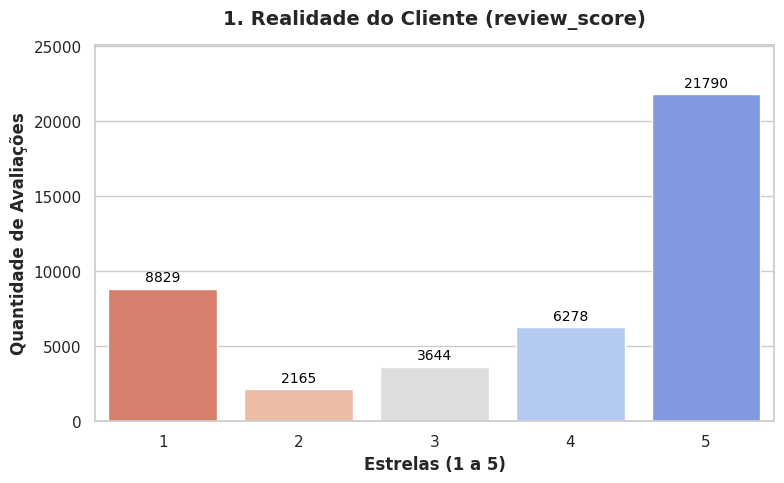

In [8]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Gráfico da Realidade
ax = sns.countplot(data=df_tratado, x='review_score', order=[1, 2, 3, 4, 5], palette="coolwarm_r")

plt.title('1. Realidade do Cliente (review_score)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Estrelas (1 a 5)', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Avaliações', fontsize=12, fontweight='bold')

# Adiciona os números no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, color='black', fontsize=10)
ax.margins(y=0.15) # Dá um espaço em cima para o número não cortar

plt.tight_layout()
plt.show()

## Usando a biblioteca Transformers para gerar score para campos (Título Comentário /Mensagem Comentário)

In [9]:
PALAVRAS_POSITIVAS = {

    "bom",
    "ótimo",
    "excelente",
    "perfeito",
    "maravilhoso",
    "incrível",
    "fantástico",
    "sensacional",
    "espetacular",
    "impecável",
    "brilhante",
    "top",
    "legal",
    "gostei",
    "adoro",
    "amei",
    "satisfeito",
    "positivo",
    "funciona",
    "recomendo",
    "eficiente",
    "10"
    "rápido",
    "bonito",
    "show",
    "melhor",
    "sucesso",
    "funciona perfeitamente",
    "vale a pena",
    "super recomendo",
    "ótimo produto",
    "excelente produto",
    "produto incrível",
    "produto maravilhoso",
    "show de bola",
    "muito bom",
    "bom demais",
    "excelente demais",
    "perfeito demais",
    "amei demais",
    "gostei muito",
    "adorei",
    "superou expectativas",
    "ótima qualidade",
    "ótima"
    "qualidade incrível",
    "vale cada centavo",
    "top demais",
    "antes do prazo"
    "muito satisfeito",
    "experiência incrível",
    "melhor compra",
    "vale muito a pena",
    "produto perfeito",
    "maravilhoso demais",
    "muito bonito",
    "design incrível",
    "funciona muito bem",
    "rápido e eficiente",
    "sem defeitos",
    "produto impecável",
    "atendimento excelente",
    "entrega rápida",
    "rapida"
    "chegou rápido",
    "chegou perfeito",
    "produto original",
    "ótimo custo benefício",
    "excelente custo benefício",
    "melhor do que esperava",
    "simplesmente perfeito",
    "simplesmente incrível",
    "bom pra caramba",
    "produto top",
    "serviço excelente",
    "produto excelente",
    "experiência perfeita",
    "qualidade excelente",
    "bom absurdo",
    "muito top",
    "bagulho bom",
    "bagulho top",
    "zika",
    "brabo",
    "insano",
    "daora",
    "show"
}

# ==========================================
# PALAVRAS NEGATIVAS
# ==========================================

PALAVRAS_NEGATIVAS = {

    # QUALIDADE RUIM
    "ruim",
    "ruimm",
    "ruuin",
    "rhuim",
    "péssimo",
    "pessimo",
    "pesssimo",
    "horrível",
    "horrivel",
    "orrivel",
    "horriveu",
    "terrível",
    "terrivel",
    "terriveu",
    "lixo",
    "lixoo",
    "lix0",
    "merda",
    "merd4",
    "porcaria",
    "porcariaa",
    "nojento",
    "ridículo",
    "ridiculo",
    "patético",
    "patetico",
    "podre",
    "horroroso",
    "trash",
    "paia",
    "feio",
    "mal feito",
    "malfeito",
    "malacabado",
    "inferior",
    "descartável",
    "descartavel",
    "problemático",
    "problematico",
    "duvidoso",
    # ADICIONAIS

"travadissimo",
"travada",
"travadeira",
"laga",
"lagadasso",
"muito lag",
"muito bug",
"buga muito",
"travando demais",
"crasha",
"crasha toda hora",
"crashando toda hora",
"instavel demais",
"lento demais",
"muito lento",
"super lento",
"lentissimo",
"pesado",
"pesadão",
"pesima qualidade",
"qualidade horrivel",
"qualidade ruim",
"acabamento ruim",
"acabamento horrível",
"acabamento horrivel",
"material ruim",
"material fraco",
"mal otimizado",
"otimização ruim",
"mal desenvolvido",
"mal produzido",
"horrendo",
"horrorivel",
"horroroso demais",
"ridiculo demais",
"muito ruim",
"extremamente ruim",
"absurdamente ruim",
"simplesmente horrível",
"simplesmente horrivel",
"simplesmente péssimo",
"simplesmente pessimo",
"deplorável",
"deploravel",
"vergonhoso",
"vergonha",
"vergonhoso demais",
"lamentável",
"lamentavel",
"tosco",
"muito tosco",
"mal acabado",
"vagabundo",
"xing ling",
"falsificado",
"falso",
"pirata",
"imprestável",
"imprestavel",
"imundo",
"porco",
"horror",
"caindo aos pedaços",
"desmanchando",
"quebra fácil",
"quebra facil",
"estraga fácil",
"estraga facil",
"durabilidade horrível",
"durabilidade horrivel",
"durou nada",
"durou nem 1 dia",
"durou nem uma semana",
"parou sozinho",
"desliga sozinho",
"reinicia sozinho",
"não durou",
"nao durou",
"não aguenta",
"nao aguenta",
"não suporta",
"nao suporta",
"não vale nada",
"nao vale nada",
"não presta mesmo",
"nao presta mesmo",
"não funciona direito",
"nao funciona direito",
"funciona mal",
"funciona porcamente",
"mal funcionamento",
"todo bugado",
"todo travado",
"vive travando",
"vive bugando",
"vive dando erro",
"dando erro",
"erro direto",
"erro constante",
"erro crítico",
"erro critico",
"erro fatal",
"falha grave",
"falha crítica",
"falha critica",
"falhou comigo",
"falhou feio",
"problemão",
"problematico demais",
"inconsistente",
"instabilidade absurda",
"interface horrível",
"interface horrivel",
"ui horrível",
"ui horrivel",
"ux horrível",
"ux horrivel",
"confuso",
"complicado",
"difícil de usar",
"dificil de usar",
"uso horrível",
"uso horrivel",
"péssima usabilidade",
"pessima usabilidade",
"desconfortável",
"desconfortavel",
"irrita",
"me irritou",
"me estressou",
"estressante",
"estressou",
"decepcionou",
"decepciona",
"frustrou",
"frustra",
"muito decepcionante",
"extremamente decepcionante",
"decepção total",
"decepcao total",
"me arrependi",
"arrependimento total",
"pior compra",
"pior produto",
"pior serviço",
"pior servico",
"pior experiência",
"pior experiencia",
"péssima compra",
"compra horrível",
"compra horrivel",
"serviço lixo",
"servico lixo",
"atendimento lixo",
"empresa lixo",
"empresa horrível",
"empresa horrivel",
"empresa ruim",
"empresa péssima",
"empresa pessima",
"suporte inexistente",
"suporte inútil",
"suporte inutil",
"atendimento horrível",
"atendimento horrivel",
"atendimento péssimo",
"atendimento pessimo",
"muito demorado",
"demora absurda",
"atraso absurdo",
"demora ridícula",
"demora ridicula",
"não respondem nunca",
"nao respondem nunca",
"ignoram cliente",
"ignoraram",
"sumiram",
"sumiram com meu pedido",
"sumiram com minha compra",
"pedido atrasado",
"pedido veio errado",
"produto veio errado",
"produto veio quebrado",
"produto veio danificado",
"produto veio incompleto",
"veio faltando peça",
"veio faltando peca",
"caixa amassada",
"embalagem ruim",
"embalagem horrível",
"embalagem horrivel",
"entrega horrível",
"entrega horrivel",
"entrega péssima",
"entrega pessima",
"nunca recebi",
"não recebi",
"nao recebi",
"não entregou",
"nao entregou",
"não enviaram",
"nao enviaram",
"enganacao",
"enganação",
"propaganda falsa",
"propaganda mentirosa",
"mentira",
"mentiroso",
"golpe total",
"furada",
"cilada",
"roubada",
"fui enganado",
"me enganaram",
"dinheiro perdido",
"joguei dinheiro no lixo",
"desperdício de dinheiro",
"desperdicio de dinheiro",
"caro demais",
"muito caro pelo que entrega",
"não compensa comprar",
"nao compensa comprar",
"não vale o investimento",
"nao vale o investimento",
"não recomendo pra ninguém",
"nao recomendo pra ninguém",
"passem longe",
"fujam disso",
"não comprem",
"nao comprem",
"não compra",
"nao compra",
"nem de graça eu quero",
"nem vale de graça",
"lixo total",
"lixo completo",
"que produto lixo",
"que produto horrível",
"que produto horrivel",
"que serviço horrível",
"que serviço horrivel",
"que atendimento horrível",
"que atendimento horrivel",
"bagulho podre",
"bagulho zoado",
"bagulho quebrado",
"bagulho bugado",
"bagulho paia",
"bagulho horrendo",
"muito meme",
"muito lixo mano",
"slk que ruim",
"slk que lixo",
"slk horrível",
"slk horrivel",
"bom só que não",
"ótimo só que não",
"otimo so que nao",
"kkk confia",
"confia kkk",
"só dor de cabeça",
"so dor de cabeca",
"só estresse",
"so estresse",
"nota 0",
"merece 0",
"merece zero",
"zero qualidade",
"qualidade zero",
"horrível do começo ao fim",
"horrivel do começo ao fim",
"péssimo do início ao fim",
"pessimo do inicio ao fim",

    # BUG / ERRO / TRAVA
    "travou",
    "travo",
    "travando",
    "trava",
    "travamento",
    "travad0",
    "lag",
    "lagado",
    "lagando",
    "lagg",
    "bug",
    "bugado",
    "buga",
    "bugou",
    "bugadoo",
    "erro",
    "errou",
    "falha",
    "falhando",
    "falhou",
    "instável",
    "instavel",
    "instabilidade",
    "crashou",
    "crasho",
    "crashando",
    "lento",
    "lentoo",
    "lentidão",
    "lentidao",

    # QUEBROU / ESTRAGOU
    "quebrou",
    "quebrô",
    "qebrou",
    "quebrado",
    "quebrada",
    "qebrado",
    "estragou",
    "estragadoo",
    "estragado",
    "estragada",
    "danificado",
    "danificada",
    "danificou",
    "frágil",
    "fragil",
    "fragiu",
    "quebradiço",
    "quebradico",
    "fraco",
    "fraquinho",
    "defeito",
    "defeituoso",
    "defeituozo",

    # FUNCIONAMENTO
    "parou",
    "parando",
    "desligou",
    "reiniciou",
    "sumiu",
    "desconectou",
    "desconecta",
    "desconectando",
    "inútil",
    "inutil",
    "inutiu",

    # FRASES NEGATIVAS
    "não funciona",
    "nao funciona",
    "n funciona",
    "naum funciona",
    "não presta",
    "nao presta",
    "naum presta",
    "não serve",
    "nao serve",
    "não abre",
    "nao abre",
    "não liga",
    "nao liga",
    "não conecta",
    "nao conecta",
    "não carrega",
    "nao carrega",
    "não responde",
    "nao responde",
    "não recomendo",
    "nao recomendo",
    "não vale a pena",
    "nao vale a pena",
    "não compensa",
    "nao compensa",
    "não vale o preço",
    "nao vale o preço",
    "nada especial",
    "não entrega o que promete",
    "nao entrega o que promete",

    # EMOÇÕES NEGATIVAS
    "odiei",
    "odeiei",
    "detestei",
    "detesteii",
    "arrependi",
    "arrependido",
    "arrempendido",
    "decepcionado",
    "decepcionante",
    "decepicionante",
    "frustrante",
    "frustante",
    "irritante",
    "raiva",
    "ódio",
    "odio",
    "estresse",
    "stress",
    "desapontado",

    # DINHEIRO
    "caro",
    "muito caro",
    "prejuízo",
    "prejuizo",
    "desperdício",
    "desperdicio",
    "roubo",
    "golpe",
    "enganado",
    "enganoso",
    "errado",

    # ENTREGA
    "atrasou",
    "demorou",
    "demorado",
    "nunca chegou",
    "não chegou",
    "nao chegou",
    "não entregaram",
    "nao entregaram",
    "pedido errado",
    "produto errado",
    "veio quebrado",
    "veio estragado",
    "veio danificado",
    "veio errado",
    "veio todo errado",
    "veio incompleto",

    # ATENDIMENTO
    "péssimo atendimento",
    "pessimo atendimento",
    "atendimento ruim",
    "suporte ruim",
    "suporte horrível",
    "suporte horrivel",
    "grosseiro",
    "maleducado",
    "ignorado",
    "descaso",

    # INTERNET / GÍRIAS
    "pqp",
    "aff",
    "afff",
    "zoado",
    "zoad0",
    "bomba",
    "bagulho ruim",
    "bagulho lixo",
    "bagulho horrível",
    "bagulho horrivel",
    "muito paia",
    "que lixo",
    "que merda",
    "nem de graça",

    # COMBINAÇÕES
    "vários problemas",
    "problemas",
    "produto horrível",
    "produto horrivel",
    "produto péssimo",
    "produto ruim",
    "produto lixo",
    "produto quebrado",
    "produto defeituoso",
    "produto inútil",
    "produto inutil",
    "produto decepcionante",
    "produto fraco",
    "serviço horrível",
    "serviço horrivel",
    "serviço ruim",
    "serviço péssimo",
    "experiência horrível",
    "experiência horrivel",
    "péssima experiência",
    "dinheiro jogado fora",
    "joguei dinheiro fora",
    "perda de tempo",
    "dor de cabeça",
    "propaganda enganosa",

    # SARCASMO
    "durou pouco",
    "parou de funcionar",
    "quebrou no primeiro dia",
    "quebrou no primeiro uso",
    "estragou rápido",
    "top demais kkk",
    "nota 10 se a escala for invertida",
    "perfeito se a intenção era me irritar"
}


In [10]:
# ================================================
# 1. BIBLIOTECAS
# ================================================
# Neste bloco são importadas as bibliotecas
# necessárias para manipulação dos dados,
# uso do modelo de linguagem, limpeza de memória,
# treinamento de algoritmos e geração de gráficos.

import pandas as pd
import numpy as np
import torch
import gc
import re
import os
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, confusion_matrix

print("==================================================")
print("🚀 INICIANDO O CAMINHO 2: CÉREBRO NATIVO PT-BR")
print("==================================================\n")

# ================================================
# 2. LIMPANDO A GPU (Prevenção de Erro de Memória)
# ================================================
# Neste bloco a memória da GPU é liberada
# antes de carregar o modelo de linguagem.
# Isso ajuda a evitar erros de memória no Colab.

torch.cuda.empty_cache()
gc.collect()

# Verifica se existe GPU disponível
device = 0 if torch.cuda.is_available() else -1

# ==========================================
# 3. LISTAS E REGRAS (Sarcasmo, Emojis, etc)
# ==========================================
# Neste bloco são definidos os elementos
# usados nas regras personalizadas de análise:
# emojis positivos, negativos, palavras de sarcasmo
# e dicionário de abreviações.

EMOJIS_POSITIVOS = ["😀","😃","😄","😁","😆","😊","😇","🙂","🙃","😉","😌","😍","🥰","😘","🤩","🥳","😋","😛","🤪","💖","💗","💓","💞","💕","💟","❣️","❤️","💛","💚","💙","💜","👍","👍🏻","👍🏼","👍🏽","👍🏾","👍🏿","👏","🙌","🤝","🙏","✨","🌟","💫","💯","🔥","🏆","🔝","✔️","✅"]
EMOJIS_NEGATIVOS = ["😡","😠","🤬","😤","😒","🙄","😬","😑","😐","😞","😔","😟","😕","🙁","☹️","😣","😖","😫","😩","🥺","😢","😭","😱","😨","😰","😓","🥴","🤢","🤮","🤡","💩","👎","👎🏻","👎🏼","👎🏽","👎🏾","👎🏿","💔","❌","🚫","🛑","📉"]
# PALAVRAS_POSITIVAS = ["bom", "ótimo", "excelente", "maravilhoso", "perfeito", "lindo", "amei", "recomendo", "top", "show"]
# PALAVRAS_NEGATIVAS = ["ruim", "péssimo", "horrível", "lixo", "odiei", "quebrado", "defeito", "demora", "lento", "nunca"]

DICIONARIO_ABREVIACOES = {
    r'\bvc\b': 'você', r'\bvcs\b': 'vocês', r'\bcmg\b': 'comigo', r'\bctg\b': 'contigo', r'\bglr\b': 'galera',
    r'\bpq\b': 'porque', r'\bmto\b': 'muito', r'\bobg\b': 'obrigado', r'\bvdd\b': 'verdade', r'\bblz\b': 'beleza',
    r'\bshow\b': 'excelente', r'\b top\b': ' excelente', r'\bñ\b': 'não', r'\bn\b': 'não', r'\bprod\b': 'produto'
}

# Substitui abreviações por palavras completas
def tratar_abreviacoes(texto):
    for padrao, substituto in DICIONARIO_ABREVIACOES.items():
        texto = re.sub(padrao, substituto, texto)
    return texto

# Penaliza previsões com baixa confiança
def ajustar_confianca(score, confianca):
    if confianca < 0.35: score -= 2
    elif confianca < 0.55: score -= 1
    return max(1, min(5, score))

# Detecta possíveis sinais de sarcasmo
def detectar_sarcasmo(texto):
    marcadores = ["kkk", "kkkk", "haha", "rsrs", "sei", "confia", "sqn"]
    tem_marcador = any(m in texto for m in marcadores)
    tem_positivo = any(p in texto for p in PALAVRAS_POSITIVAS)
    tem_negativo = any(n in texto for n in PALAVRAS_NEGATIVAS)
    return (tem_positivo and tem_negativo) or (tem_marcador and tem_positivo)

# ==========================================
# 4. CARREGAMENTO DOS DADOS ORIGINAIS
# ==========================================
# Neste bloco os dados originais são carregados,
# linhas inválidas são removidas e os textos
# são padronizados para análise.

print("Carregando e limpando os dados...")

# Remove linhas com nota ausente
df_tratado = df.dropna(subset=['review_score']).copy()

# Remove linhas sem título e sem mensagem
df_tratado = df_tratado.dropna(subset=['review_comment_title', 'review_comment_message'], how='all')

# Limpeza e padronização dos textos
for col in ['review_comment_title', 'review_comment_message']:
    df_tratado[col] = df_tratado[col].fillna('').str.lower().str.replace(r'[\n\r]+', ' ', regex=True).str.replace(r'\s+', ' ', regex=True).str.strip()
    df_tratado[col] = [tratar_abreviacoes(t) for t in df_tratado[col]]

# ==========================================
# 5. NOVO MODELO (NATIVO PT-BR)
# ==========================================
# Neste bloco é carregado um modelo nativo
# treinado para análise de sentimentos em português.
# Em seguida, títulos e mensagens são processados.

print("\nBaixando/Carregando o modelo nativo em Português...")

# Modelo treinado para sentimentos latinos (PT, ES, EN)
model_name = "pysentimiento/robertuito-sentiment-analysis"
classificador = pipeline("text-classification", model=model_name, tokenizer=model_name, device=device)

textos_titulo = df_tratado['review_comment_title'].replace('', 'ok').tolist()
textos_mensagem = df_tratado['review_comment_message'].replace('', 'ok').tolist()

print("Analisando os Títulos (GPU)...")
resultados_titulo = classificador(textos_titulo, batch_size=64, truncation=True, max_length=128)

print("Analisando as Mensagens (GPU)...")
resultados_mensagem = classificador(textos_mensagem, batch_size=64, truncation=True, max_length=128)

# ==========================================
# 6. REGRAS DE OURO + MAPEAMENTO
# ==========================================
# Neste bloco as saídas do modelo são combinadas
# com regras de sarcasmo, emojis e confiança
# para gerar notas finais entre 1 e 5.

def definir_nota_final_pt(resultado_hf, texto_original):
    if texto_original == '':
        return 3

    if detectar_sarcasmo(texto_original):
        return 1

    pos_count = sum(1 for char in texto_original if char in EMOJIS_POSITIVOS)
    neg_count = sum(1 for char in texto_original if char in EMOJIS_NEGATIVOS)

    if pos_count > neg_count:
        return 5
    elif neg_count > pos_count:
        return 1

    # Mapeando POS, NEU, NEG para as estrelas
    label = resultado_hf.get('label', 'NEU').upper()

    if 'POS' in label:
        nota_limpa = 5
    elif 'NEG' in label:
        nota_limpa = 1
    else:
        nota_limpa = 3

    confianca_ia = resultado_hf.get('score', 1.0)

    return ajustar_confianca(nota_limpa, confianca_ia)

# Aplica a regra aos títulos
df_tratado['nota_titulo'] = [
    definir_nota_final_pt(res, txt)
    for res, txt in zip(resultados_titulo, df_tratado['review_comment_title'])
]

# Aplica a regra às mensagens
df_tratado['nota_mensagem'] = [
    definir_nota_final_pt(res, txt)
    for res, txt in zip(resultados_mensagem, df_tratado['review_comment_message'])
]


df_tratado = df_tratado[['review_score', 'review_comment_title','nota_titulo', 'review_comment_message','nota_mensagem']].copy()

df_tratado[["nota_titulo","nota_mensagem"]] = df_tratado[["nota_titulo","nota_mensagem"]].astype("Int8")

output_dir = '/content/df_pronto_regressao_transformers'
os.makedirs(output_dir, exist_ok=True)

df_tratado.to_parquet(os.path.join(output_dir, 'Transformers_Resultados.parquet'),index=False)
print("\nArquivo 'df_pronto_regressao.parquet' salvo na pasta do Colab!")


🚀 INICIANDO O CAMINHO 2: CÉREBRO NATIVO PT-BR

Carregando e limpando os dados...

Baixando/Carregando o modelo nativo em Português...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/435M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Analisando os Títulos (GPU)...
Analisando as Mensagens (GPU)...

Arquivo 'df_pronto_regressao.parquet' salvo na pasta do Colab!


/tmp/ipykernel_7804/3058379839.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_trans, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")


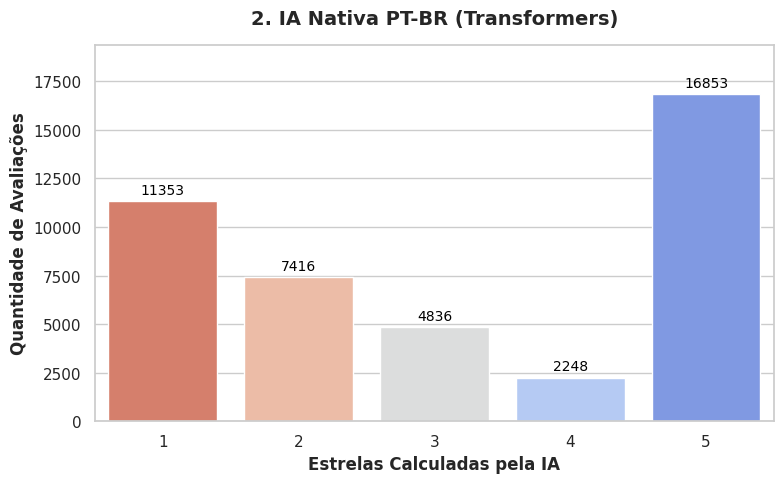

In [11]:
caminho_trans = '/content/df_pronto_regressao_transformers/Transformers_Resultados.parquet'
df_trans = pd.read_parquet(caminho_trans)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Gráfico Transformers
ax = sns.countplot(data=df_trans, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")

plt.title('2. IA Nativa PT-BR (Transformers)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Estrelas Calculadas pela IA', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Avaliações', fontsize=12, fontweight='bold')

# Adiciona os números no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, color='black', fontsize=10)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

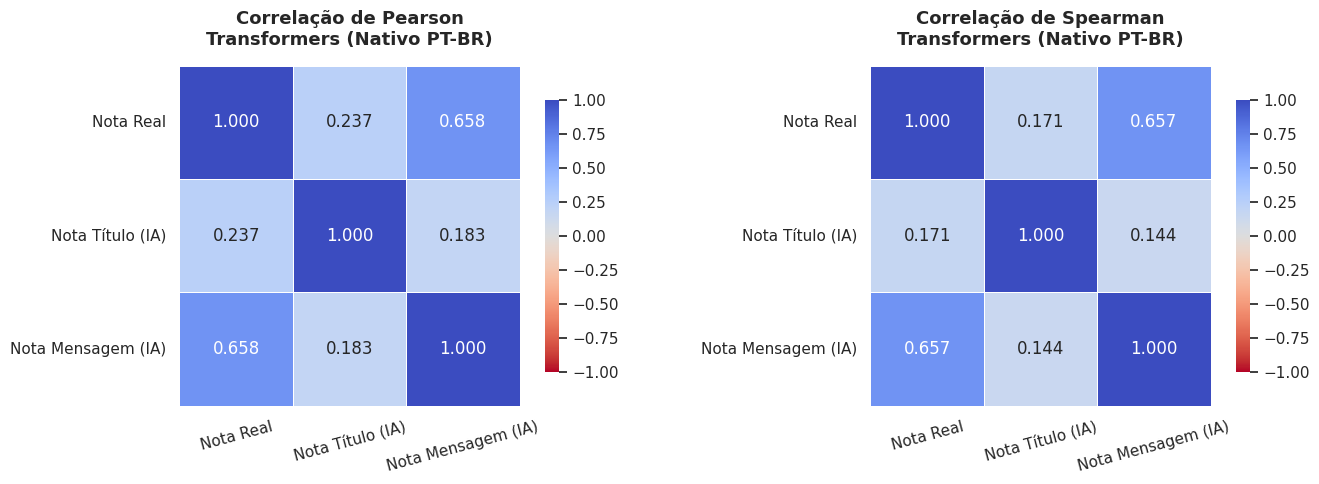

In [12]:
# 1. Carregamento do arquivo
caminho_trans = '/content/df_pronto_regressao_transformers/Transformers_Resultados.parquet'
df_trans = pd.read_parquet(caminho_trans)

# 2. Preparação dos dados
colunas_alvo = ['review_score', 'nota_titulo', 'nota_mensagem']
nomes_eixos = ['Nota Real', 'Nota Título (IA)', 'Nota Mensagem (IA)']

df_corr = df_trans[colunas_alvo].dropna().astype(float)
df_corr.columns = nomes_eixos

# 3. Cálculo das Correlações
matriz_pearson = df_corr.corr(method='pearson')
matriz_spearman = df_corr.corr(method='spearman')

# 4. Plotagem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")
cmap = "coolwarm_r"

# Heatmap Pearson
sns.heatmap(matriz_pearson, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].set_title('Correlação de Pearson\nTransformers (Nativo PT-BR)', fontsize=13, fontweight='bold', pad=15)

# Heatmap Spearman
sns.heatmap(matriz_spearman, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title('Correlação de Spearman\nTransformers (Nativo PT-BR)', fontsize=13, fontweight='bold', pad=15)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

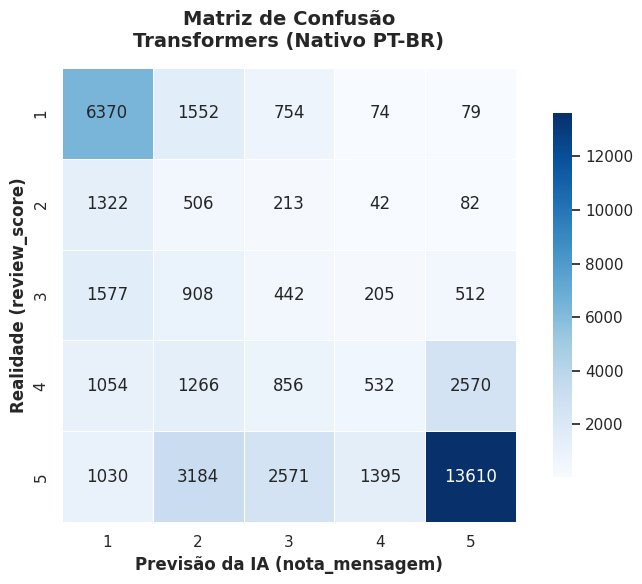

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Carregamento do arquivo
caminho_trans = '/content/df_pronto_regressao_transformers/Transformers_Resultados.parquet'
df_trans = pd.read_parquet(caminho_trans)

# 2. Limpeza de nulos e conversão para inteiros
df_cm = df_trans[['review_score', 'nota_mensagem']].dropna().astype(int)

# 3. Cálculo da Matriz de Confusão
labels_estrelas = [1, 2, 3, 4, 5]
cm = confusion_matrix(df_cm['review_score'], df_cm['nota_mensagem'], labels=labels_estrelas)

# 4. Plotagem
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# fmt='d' garante que os números apareçam como inteiros exatos
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_estrelas, yticklabels=labels_estrelas,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Confusão\nTransformers (Nativo PT-BR)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Realidade (review_score)', fontsize=12, fontweight='bold')
plt.xlabel('Previsão da IA (nota_mensagem)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
a = df_trans.query("review_score == 5 and nota_mensagem == 1")
a.head(20)

/tmp/ipykernel_7804/3476948097.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  a = df_trans.query("review_score == 5 and nota_mensagem == 1")


,review_score,review_comment_title,nota_titulo,review_comment_message,nota_mensagem
53,5,,3,super rapido a entrega .... chegou antes da da...,1
83,5,,3,ainda não tive a oportunidade de testar,1
157,5,,3,acho q deveriam mandar por sedex ao invés de pac,1
188,5,produto fraco,1,quanto ao site não tenho o que questionar! sem...,1
230,5,,3,"recomendo a todos. produto de ótima qualidade,...",1
259,5,,3,só poderia entregar mais rápido fim de ano,1
279,5,,3,parabéns 😤 pelo excelente atendimento de quali...,1
326,5,regular,2,loja em si é boa pena a americana nao da supor...,1
358,5,,3,entrega muito rapida,1
379,5,,3,muito satisfeito entrega super rápida.. excele...,1


In [15]:
df_trans.query("review_score == 5 and nota_mensagem == 2")

/tmp/ipykernel_7804/3873145870.py:1: RuntimeWarning: Engine has switched to 'python' because numexpr does not support extension array dtypes. Please set your engine to python manually.
  df_trans.query("review_score == 5 and nota_mensagem == 2")


,review_score,review_comment_title,nota_titulo,review_comment_message,nota_mensagem
0,5,,3,recebi bem antes do prazo estipulado.,2
4,5,super recomendo,5,"vendedor confiável, produto ok e entrega antes...",2
7,5,ótimo,2,loja nota 10,2
14,5,bom,2,"recomendo ,",2
40,5,***** recomendo,3,super rápido.,2
...,...,...,...,...,...
42667,5,bom,2,produto veio conforme especificações.,2
42668,5,,3,vendedor compromisso do vou o cliente,2
42677,5,,3,veio por partes mas veio tudo certo!,2
42683,5,entrega super rápida,3,super antes do prazo!!!,2


______________________________________________________________________________
## Usando a biblioteca leAI para gerar score para campos (Título Comentário /Mensagem Comentário)

In [16]:
# ==========================================
# 1. SETUP E DOWNLOAD DO LeIA OFICIAL
# ==========================================
# Baixa a pasta inteira e original do modelo direto do criador
!git clone -q https://github.com/rafjaa/LeIA.git

# ==========================================
# 2. BIBLIOTECAS
# ==========================================
import sys
import os
sys.path.append('/content/LeIA')
import pandas as pd
import re
from leia import SentimentIntensityAnalyzer

print("==================================================")
print("🚀 INICIANDO O CAMINHO: VADER (LeIA) - ESCALA 1 a 5")
print("==================================================\n")

# ==========================================
# 3. LISTAS E REGRAS (Sarcasmo, Emojis, etc)
# ==========================================
EMOJIS_POSITIVOS = ["😀","😃","😄","😁","😆","😊","😇","🙂","🙃","😉","😌","😍","🥰","😘","🤩","🥳","😋","😛","🤪","💖","💗","💓","💞","💕","💟","❣️","❤️","💛","💚","💙","💜","👍","👍🏻","👍🏼","👍🏽","👍🏾","👍🏿","👏","🙌","🤝","🙏","✨","🌟","💫","💯","🔥","🏆","🔝","✔️","✅"]
EMOJIS_NEGATIVOS = ["😡","😠","🤬","😤","😒","🙄","😬","😑","😐","😞","😔","😟","😕","🙁","☹️","😣","😖","😫","😩","🥺","😢","😭","😱","😨","😰","😓","🥴","🤢","🤮","🤡","💩","👎","👎🏻","👎🏼","👎🏽","👎🏾","👎🏿","💔","❌","🚫","🛑","📉"]
# PALAVRAS_POSITIVAS = ["bom", "ótimo", "excelente", "maravilhoso", "perfeito", "lindo", "amei", "recomendo", "top", "show"]
# PALAVRAS_NEGATIVAS = ["ruim", "péssimo", "horrível", "lixo", "odiei", "quebrado", "defeito", "demora", "lento", "nunca"]

DICIONARIO_ABREVIACOES = {
    r'\bvc\b': 'você', r'\bvcs\b': 'vocês', r'\bcmg\b': 'comigo', r'\bctg\b': 'contigo', r'\bglr\b': 'galera',
    r'\bpq\b': 'porque', r'\bmto\b': 'muito', r'\bobg\b': 'obrigado', r'\bvdd\b': 'verdade', r'\bblz\b': 'beleza',
    r'\bshow\b': 'excelente', r'\b top\b': ' excelente', r'\bñ\b': 'não', r'\bn\b': 'não', r'\bprod\b': 'produto'
}

# Substitui abreviações por palavras completas
def tratar_abreviacoes(texto):
    for padrao, substituto in DICIONARIO_ABREVIACOES.items():
        texto = re.sub(padrao, substituto, texto)
    return texto

# Detecta possíveis sinais de sarcasmo
def detectar_sarcasmo(texto):
    marcadores = ["kkk", "kkkk", "haha", "rsrs", "sei", "confia", "sqn"]
    tem_marcador = any(m in texto for m in marcadores)
    tem_positivo = any(p in texto for p in PALAVRAS_POSITIVAS)
    tem_negativo = any(n in texto for n in PALAVRAS_NEGATIVAS)
    return (tem_positivo and tem_negativo) or (tem_marcador and tem_positivo)

# ==========================================
# 4. CARREGAMENTO E LIMPEZA DOS DADOS
# ==========================================
print("Carregando, traduzindo abreviações e limpando os dados...")

df_tratado = df.dropna(subset=['review_score']).copy()
df_tratado = df_tratado.dropna(subset=['review_comment_title', 'review_comment_message'], how='all')

colunas_texto = ['review_comment_title', 'review_comment_message']
for col in colunas_texto:
    df_tratado[col] = df_tratado[col].fillna('')
    df_tratado[col] = df_tratado[col].str.lower()
    df_tratado[col] = df_tratado[col].str.replace(r'[\n\r]+', ' ', regex=True)
    df_tratado[col] = df_tratado[col].str.replace(r'\s+', ' ', regex=True).str.strip()
    df_tratado[col] = [tratar_abreviacoes(t) for t in df_tratado[col]]

# ==========================================
# 5. SETUP DO VADER (LeIA) E PROCESSAMENTO
# ==========================================
print("\nCarregando o VADER para Português...")
analisador = SentimentIntensityAnalyzer()

textos_titulo = df_tratado['review_comment_title'].replace('', 'ok').tolist()
textos_mensagem = df_tratado['review_comment_message'].replace('', 'ok').tolist()

print("Analisando sentimentos...")
resultados_titulo = [analisador.polarity_scores(txt) for txt in textos_titulo]
resultados_mensagem = [analisador.polarity_scores(txt) for txt in textos_mensagem]

# ================================================
# 6. MONTAGEM DA TABELA FINAL (REGRAS PADRONIZADAS)
# ================================================
print("\nAplicando Regras de Ouro e montando a base final...")

def definir_nota_final_vader(resultado_vader, texto_original):
    # Regra 1: Se for vazio ou apenas "ok" da limpeza, nota neutra
    if texto_original == '' or texto_original == 'ok':
        return 3

    # Regra 2: Sarcasmo (Conforme modelo padrão)
    if detectar_sarcasmo(texto_original):
        return 1

    # Regra 3: Prioridade Absoluta dos Emojis (Conforme modelo padrão)
    pos_count = sum(1 for char in texto_original if char in EMOJIS_POSITIVOS)
    neg_count = sum(1 for char in texto_original if char in EMOJIS_NEGATIVOS)

    if pos_count > neg_count:
        return 5
    elif neg_count > pos_count:
        return 1

    # Regra 4: IA assume o controle (Mapeamento do Compound VADER)
    compound = resultado_vader['compound']

    if compound >= 0.5:
        return 5
    elif compound >= 0.05:
        return 4
    elif compound > -0.05:
        return 3
    elif compound > -0.5:
        return 2
    else:
        return 1

# Aplicando a função
df_tratado['nota_titulo'] = [
    definir_nota_final_vader(res, txt) for res, txt in zip(resultados_titulo, df_tratado['review_comment_title'])
]

df_tratado['nota_mensagem'] = [
    definir_nota_final_vader(res, txt) for res, txt in zip(resultados_mensagem, df_tratado['review_comment_message'])
]

df_final = df_tratado[['review_score', 'review_comment_title', 'nota_titulo', 'review_comment_message', 'nota_mensagem']].copy()

# Padronizando o tipo das notas igual ao Transformer
df_final[["nota_titulo","nota_mensagem"]] = df_final[["nota_titulo","nota_mensagem"]].astype("Int8")

print("\n=== CONCLUÍDO COM SUCESSO! ===")

# ==========================================
# 7. SALVAMENTO DOS RESULTADOS
# ==========================================
output_dir = '/content/df_pronto_regressao_vader-leIA'
os.makedirs(output_dir, exist_ok=True)

df_final.to_parquet(os.path.join(output_dir, 'LeIA_Resultados.parquet'), index=False)
print(f"\nArquivo 'LeIA_Resultados.parquet' salvo em: {output_dir}")

🚀 INICIANDO O CAMINHO: VADER (LeIA) - ESCALA 1 a 5

Carregando, traduzindo abreviações e limpando os dados...

Carregando o VADER para Português...
Analisando sentimentos...

Aplicando Regras de Ouro e montando a base final...

=== CONCLUÍDO COM SUCESSO! ===

Arquivo 'LeIA_Resultados.parquet' salvo em: /content/df_pronto_regressao_vader-leIA


/tmp/ipykernel_7804/1174286461.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_leia, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")


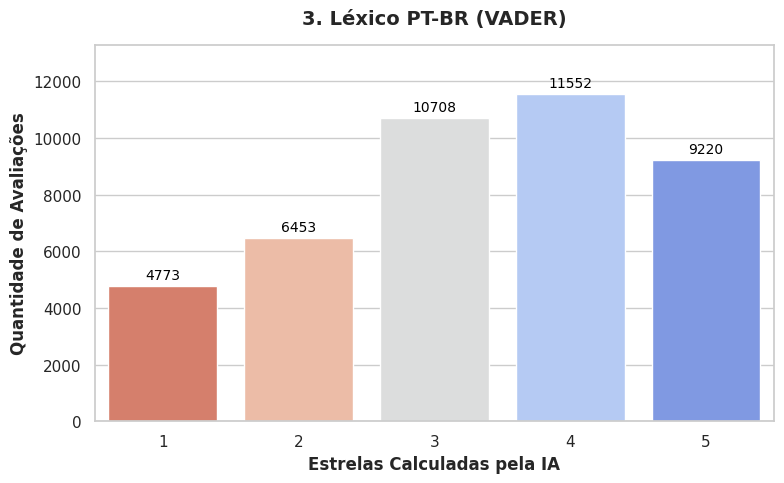

In [17]:
caminho_leia = '/content/df_pronto_regressao_vader-leIA/LeIA_Resultados.parquet'
df_leia = pd.read_parquet(caminho_leia)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Gráfico LeIA
ax = sns.countplot(data=df_leia, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")

plt.title('3. Léxico PT-BR (VADER)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Estrelas Calculadas pela IA', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Avaliações', fontsize=12, fontweight='bold')

# Adiciona os números no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, color='black', fontsize=10)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

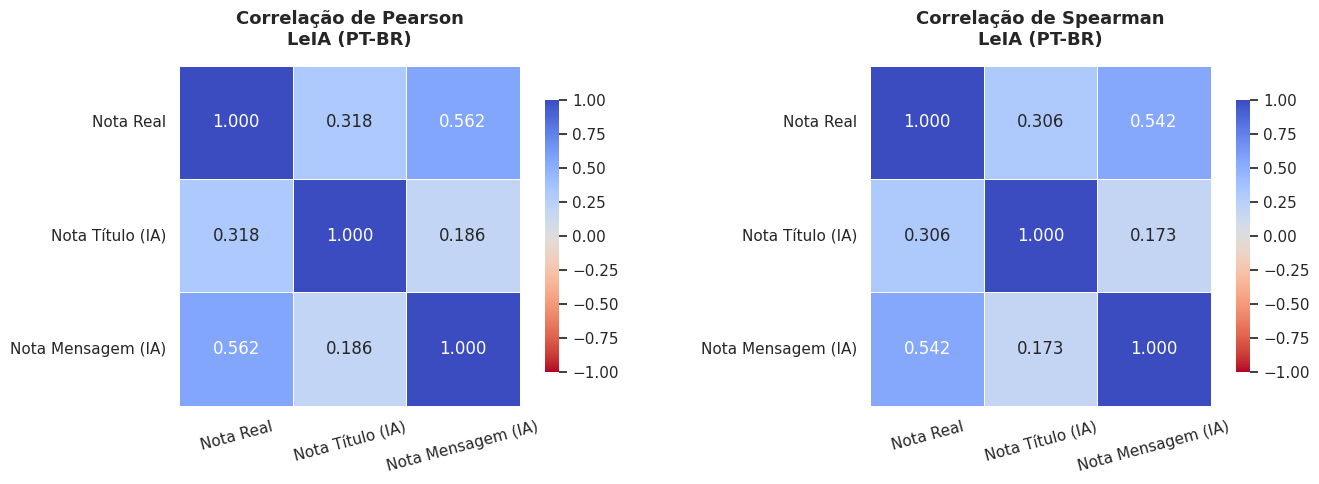

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregamento do arquivo
caminho_leia = '/content/df_pronto_regressao_vader-leIA/LeIA_Resultados.parquet'
df_leia = pd.read_parquet(caminho_leia)

# 2. Preparação dos dados
colunas_alvo = ['review_score', 'nota_titulo', 'nota_mensagem']
nomes_eixos = ['Nota Real', 'Nota Título (IA)', 'Nota Mensagem (IA)']

df_corr = df_leia[colunas_alvo].dropna().astype(float)
df_corr.columns = nomes_eixos

# 3. Cálculo das Correlações
matriz_pearson = df_corr.corr(method='pearson')
matriz_spearman = df_corr.corr(method='spearman')

# 4. Plotagem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")
cmap = "coolwarm_r"

# Heatmap Pearson
sns.heatmap(matriz_pearson, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].set_title('Correlação de Pearson\nLeIA (PT-BR)', fontsize=13, fontweight='bold', pad=15)

# Heatmap Spearman
sns.heatmap(matriz_spearman, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title('Correlação de Spearman\nLeIA (PT-BR)', fontsize=13, fontweight='bold', pad=15)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

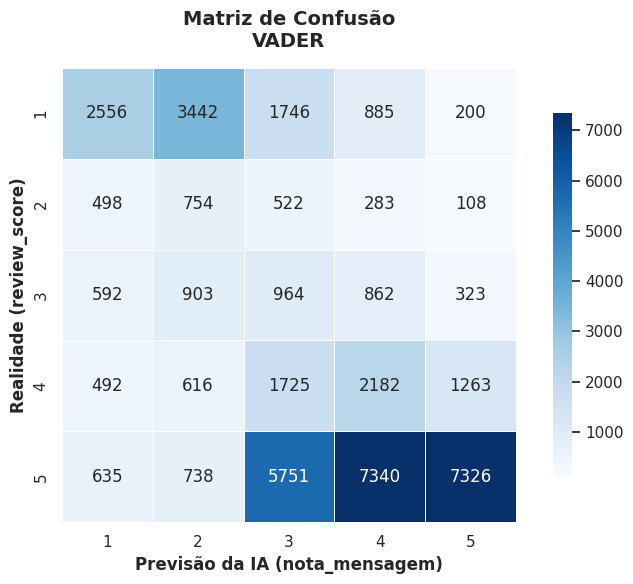

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Carregamento do arquivo
caminho_leia = '/content/df_pronto_regressao_vader-leIA/LeIA_Resultados.parquet'
df_leia = pd.read_parquet(caminho_leia)

# 2. Limpeza de nulos e conversão para inteiros
df_cm = df_leia[['review_score', 'nota_mensagem']].dropna().astype(int)

# 3. Cálculo da Matriz de Confusão
labels_estrelas = [1, 2, 3, 4, 5]
cm = confusion_matrix(df_cm['review_score'], df_cm['nota_mensagem'], labels=labels_estrelas)

# 4. Plotagem
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_estrelas, yticklabels=labels_estrelas,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Confusão\nVADER', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Realidade (review_score)', fontsize=12, fontweight='bold')
plt.xlabel('Previsão da IA (nota_mensagem)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

_____________________________________________________________________
## Usando a biblioteca TextBlob para gerar score para campos (Título Comentário /Mensagem Comentário)

In [20]:
# ==========================================
# 0. INSTALAÇÃO (Se necessário)
# ==========================================
!pip install -q textblob

# ==========================================
# 1. BIBLIOTECAS
# ==========================================
import pandas as pd
import re
import os
from textblob import TextBlob

print("==================================================")
print("🚀 INICIANDO O CAMINHO: TEXTBLOB - ESCALA 1 a 5")
print("==================================================\n")

# ==========================================
# 2. LISTAS E REGRAS (Sarcasmo, Emojis, etc)
# ==========================================
EMOJIS_POSITIVOS = ["😀","😃","😄","😁","😆","😊","😇","🙂","🙃","😉","😌","😍","🥰","😘","🤩","🥳","😋","😛","🤪","💖","💗","💓","💞","💕","💟","❣️","❤️","💛","💚","💙","💜","👍","👍🏻","👍🏼","👍🏽","👍🏾","👍🏿","👏","🙌","🤝","🙏","✨","🌟","💫","💯","🔥","🏆","🔝","✔️","✅"]
EMOJIS_NEGATIVOS = ["😡","😠","🤬","😤","😒","🙄","😬","😑","😐","😞","😔","😟","😕","🙁","☹️","😣","😖","😫","😩","🥺","😢","😭","😱","😨","😰","😓","🥴","🤢","🤮","🤡","💩","👎","👎🏻","👎🏼","👎🏽","👎🏾","👎🏿","💔","❌","🚫","🛑","📉"]
# PALAVRAS_POSITIVAS = ["bom", "ótimo", "excelente", "maravilhoso", "perfeito", "lindo", "amei", "recomendo", "top", "show"]
# PALAVRAS_NEGATIVAS = ["ruim", "péssimo", "horrível", "lixo", "odiei", "quebrado", "defeito", "demora", "lento", "nunca"]

DICIONARIO_ABREVIACOES = {
    r'\bvc\b': 'você', r'\bvcs\b': 'vocês', r'\bcmg\b': 'comigo', r'\bctg\b': 'contigo', r'\bglr\b': 'galera',
    r'\bpq\b': 'porque', r'\bmto\b': 'muito', r'\bobg\b': 'obrigado', r'\bvdd\b': 'verdade', r'\bblz\b': 'beleza',
    r'\bshow\b': 'excelente', r'\b top\b': ' excelente', r'\bñ\b': 'não', r'\bn\b': 'não', r'\bprod\b': 'produto'
}

# Substitui abreviações por palavras completas
def tratar_abreviacoes(texto):
    for padrao, substituto in DICIONARIO_ABREVIACOES.items():
        texto = re.sub(padrao, substituto, texto)
    return texto

# Detecta possíveis sinais de sarcasmo
def detectar_sarcasmo(texto):
    marcadores = ["kkk", "kkkk", "haha", "rsrs", "sei", "confia", "sqn"]
    tem_marcador = any(m in texto for m in marcadores)
    tem_positivo = any(p in texto for p in PALAVRAS_POSITIVAS)
    tem_negativo = any(n in texto for n in PALAVRAS_NEGATIVAS)
    return (tem_positivo and tem_negativo) or (tem_marcador and tem_positivo)

# ==========================================
# 3. CARREGAMENTO E LIMPEZA DOS DADOS
# ==========================================
print("Carregando, traduzindo abreviações e limpando os dados...")

# Remove target nulo e linhas sem nenhum texto
df_tratado = df.dropna(subset=['review_score']).copy()
df_tratado = df_tratado.dropna(subset=['review_comment_title', 'review_comment_message'], how='all')

# Padroniza textos, preenche nulos e aplica abreviações
colunas_texto = ['review_comment_title', 'review_comment_message']
for col in colunas_texto:
    df_tratado[col] = df_tratado[col].fillna('')
    df_tratado[col] = df_tratado[col].str.lower()
    df_tratado[col] = df_tratado[col].str.replace(r'[\n\r]+', ' ', regex=True)
    df_tratado[col] = df_tratado[col].str.replace(r'\s+', ' ', regex=True).str.strip()
    df_tratado[col] = [tratar_abreviacoes(t) for t in df_tratado[col]]

# ==========================================
# 4. PROCESSAMENTO TEXTBLOB E REGRAS PADRÃO
# ==========================================
print("\nIniciando TextBlob... (Isso pode demorar devido à tradução das frases online)")

def definir_nota_final_textblob(texto_original):
    # Regra 1: Se for vazio ou "ok" da limpeza, nota neutra
    if texto_original == '' or texto_original == 'ok':
        return 3

    # Regra 2: Sarcasmo garante nota mínima
    if detectar_sarcasmo(texto_original):
        return 1

    # Regra 3: Prioridade Absoluta dos Emojis
    pos_count = sum(1 for char in texto_original if char in EMOJIS_POSITIVOS)
    neg_count = sum(1 for char in texto_original if char in EMOJIS_NEGATIVOS)

    if pos_count > neg_count:
        return 5  # Emoji Positivo ganha
    elif neg_count > pos_count:
        return 1  # Emoji Negativo ganha

    # Regra 4: IA assume o controle (TextBlob)
    polaridade = 0.0
    try:
        # Tenta traduzir a frase para o inglês para o TextBlob entender melhor
        if len(texto_original) > 2: # Evita erro com frases curtas demais
            blob = TextBlob(texto_original)
            polaridade = blob.translate(from_lang='pt', to='en').sentiment.polarity
    except:
        # Se a internet falhar ou a API bloquear, avalia em PT mesmo (geralmente vai tender ao neutro)
        polaridade = TextBlob(texto_original).sentiment.polarity

    # Mapeando o valor contínuo do TextBlob (-1.0 a +1.0) para as 5 estrelas
    if polaridade >= 0.5:
        return 5
    elif polaridade >= 0.05:
        return 4
    elif polaridade > -0.05:
        return 3
    elif polaridade > -0.5:
        return 2
    else:
        return 1

# Processando linha a linha
df_tratado['nota_titulo'] = [
    definir_nota_final_textblob(txt) for txt in df_tratado['review_comment_title']
]

print("Títulos concluídos! Processando Mensagens...")

df_tratado['nota_mensagem'] = [
    definir_nota_final_textblob(txt) for txt in df_tratado['review_comment_message']
]

# ==========================================
# 5. MONTAGEM DA TABELA FINAL
# ==========================================
df_final = df_tratado[['review_score', 'review_comment_title', 'nota_titulo', 'review_comment_message', 'nota_mensagem']].copy()

# Padronizando o tipo das notas igual aos outros modelos
df_final[["nota_titulo","nota_mensagem"]] = df_final[["nota_titulo","nota_mensagem"]].astype("Int8")

print("\n=== CONCLUÍDO COM SUCESSO! ===")

# ==========================================
# 6. SALVAMENTO DOS RESULTADOS
# ==========================================
output_dir = '/content/df_pronto_regressao_textblob'
os.makedirs(output_dir, exist_ok=True)

df_final.to_parquet(os.path.join(output_dir, 'TextBlob_Resultados.parquet'), index=False)
print(f"\nArquivo 'TextBlob_Resultados.parquet' salvo em: {output_dir}")

🚀 INICIANDO O CAMINHO: TEXTBLOB - ESCALA 1 a 5

Carregando, traduzindo abreviações e limpando os dados...

Iniciando TextBlob... (Isso pode demorar devido à tradução das frases online)
Títulos concluídos! Processando Mensagens...

=== CONCLUÍDO COM SUCESSO! ===

Arquivo 'TextBlob_Resultados.parquet' salvo em: /content/df_pronto_regressao_textblob


/tmp/ipykernel_7804/3537410270.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_textblob, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")


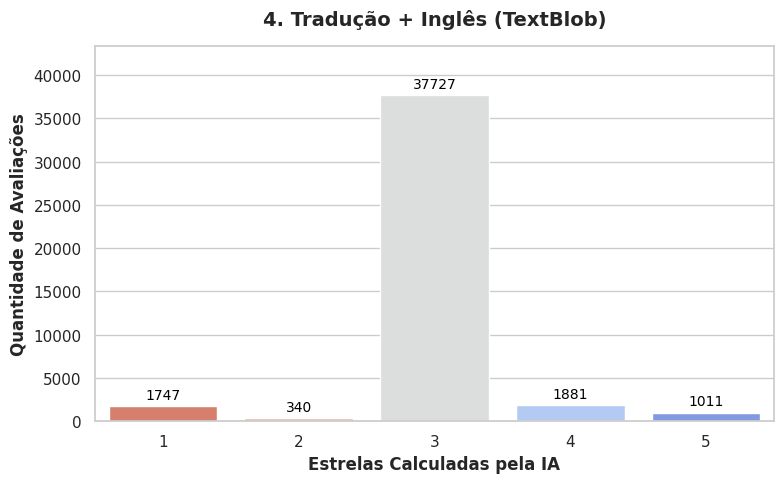

In [21]:
caminho_textblob = '/content/df_pronto_regressao_textblob/TextBlob_Resultados.parquet'
df_textblob = pd.read_parquet(caminho_textblob)

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

# Gráfico TextBlob
ax = sns.countplot(data=df_textblob, x='nota_mensagem', order=[1, 2, 3, 4, 5], palette="coolwarm_r")

plt.title('4. Tradução + Inglês (TextBlob)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Estrelas Calculadas pela IA', fontsize=12, fontweight='bold')
plt.ylabel('Quantidade de Avaliações', fontsize=12, fontweight='bold')

# Adiciona os números no topo das barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, color='black', fontsize=10)
ax.margins(y=0.15)

plt.tight_layout()
plt.show()

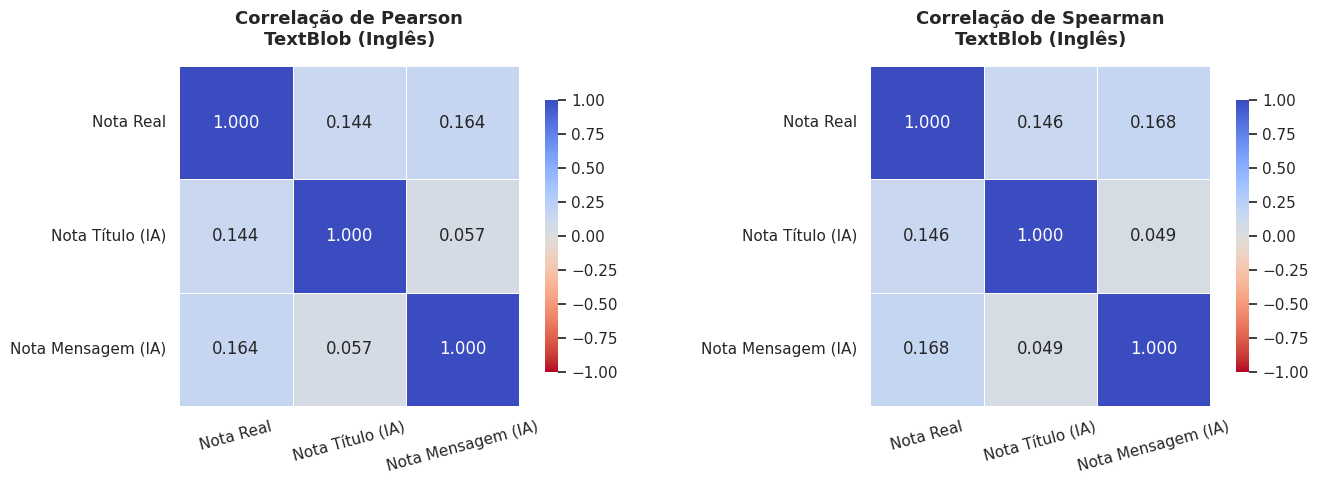

In [22]:
# 1. Carregamento do arquivo
caminho_textblob = '/content/df_pronto_regressao_textblob/TextBlob_Resultados.parquet'
df_textblob = pd.read_parquet(caminho_textblob)

# 2. Preparação dos dados
colunas_alvo = ['review_score', 'nota_titulo', 'nota_mensagem']
nomes_eixos = ['Nota Real', 'Nota Título (IA)', 'Nota Mensagem (IA)']

df_corr = df_textblob[colunas_alvo].dropna().astype(float)
df_corr.columns = nomes_eixos

# 3. Cálculo das Correlações
matriz_pearson = df_corr.corr(method='pearson')
matriz_spearman = df_corr.corr(method='spearman')

# 4. Plotagem
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.set_theme(style="white")
cmap = "coolwarm_r"

# Heatmap Pearson
sns.heatmap(matriz_pearson, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[0], cbar_kws={"shrink": .8})
axes[0].set_title('Correlação de Pearson\nTextBlob (Inglês)', fontsize=13, fontweight='bold', pad=15)

# Heatmap Spearman
sns.heatmap(matriz_spearman, annot=True, fmt=".3f", cmap=cmap, vmin=-1, vmax=1,
            square=True, linewidths=.5, ax=axes[1], cbar_kws={"shrink": .8})
axes[1].set_title('Correlação de Spearman\nTextBlob (Inglês)', fontsize=13, fontweight='bold', pad=15)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

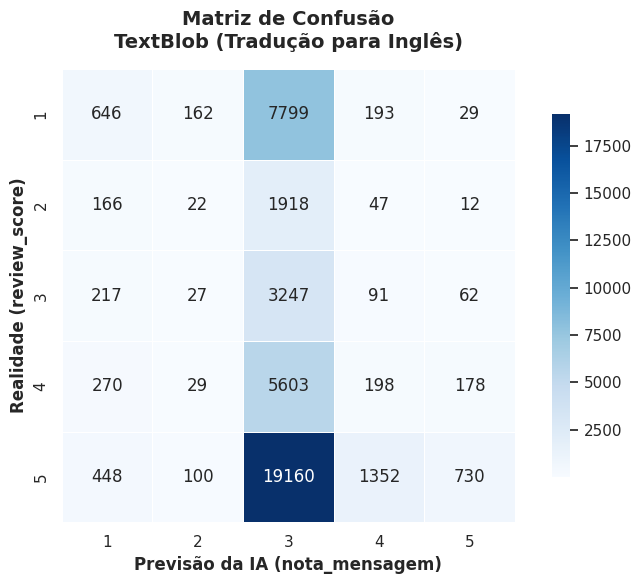

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Carregamento do arquivo
caminho_textblob = '/content/df_pronto_regressao_textblob/TextBlob_Resultados.parquet'
df_textblob = pd.read_parquet(caminho_textblob)

# 2. Limpeza de nulos e conversão para inteiros
df_cm = df_textblob[['review_score', 'nota_mensagem']].dropna().astype(int)

# 3. Cálculo da Matriz de Confusão
labels_estrelas = [1, 2, 3, 4, 5]
cm = confusion_matrix(df_cm['review_score'], df_cm['nota_mensagem'], labels=labels_estrelas)

# 4. Plotagem
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_estrelas, yticklabels=labels_estrelas,
            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Matriz de Confusão\nTextBlob (Tradução para Inglês)', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Realidade (review_score)', fontsize=12, fontweight='bold')
plt.xlabel('Previsão da IA (nota_mensagem)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7804/473731121.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_tratado, x='review_score', order=ordem_estrelas, palette=paleta, ax=axes[0, 0])
/tmp/ipykernel_7804/473731121.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_trans, x='nota_mensagem', order=ordem_estrelas, palette=paleta, ax=axes[0, 1])
/tmp/ipykernel_7804/473731121.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_leia, x='nota_mensagem', order=ordem_estrelas, palette=paleta, ax=axes[1, 0])
/tmp/ipykernel_7804/473731121.p

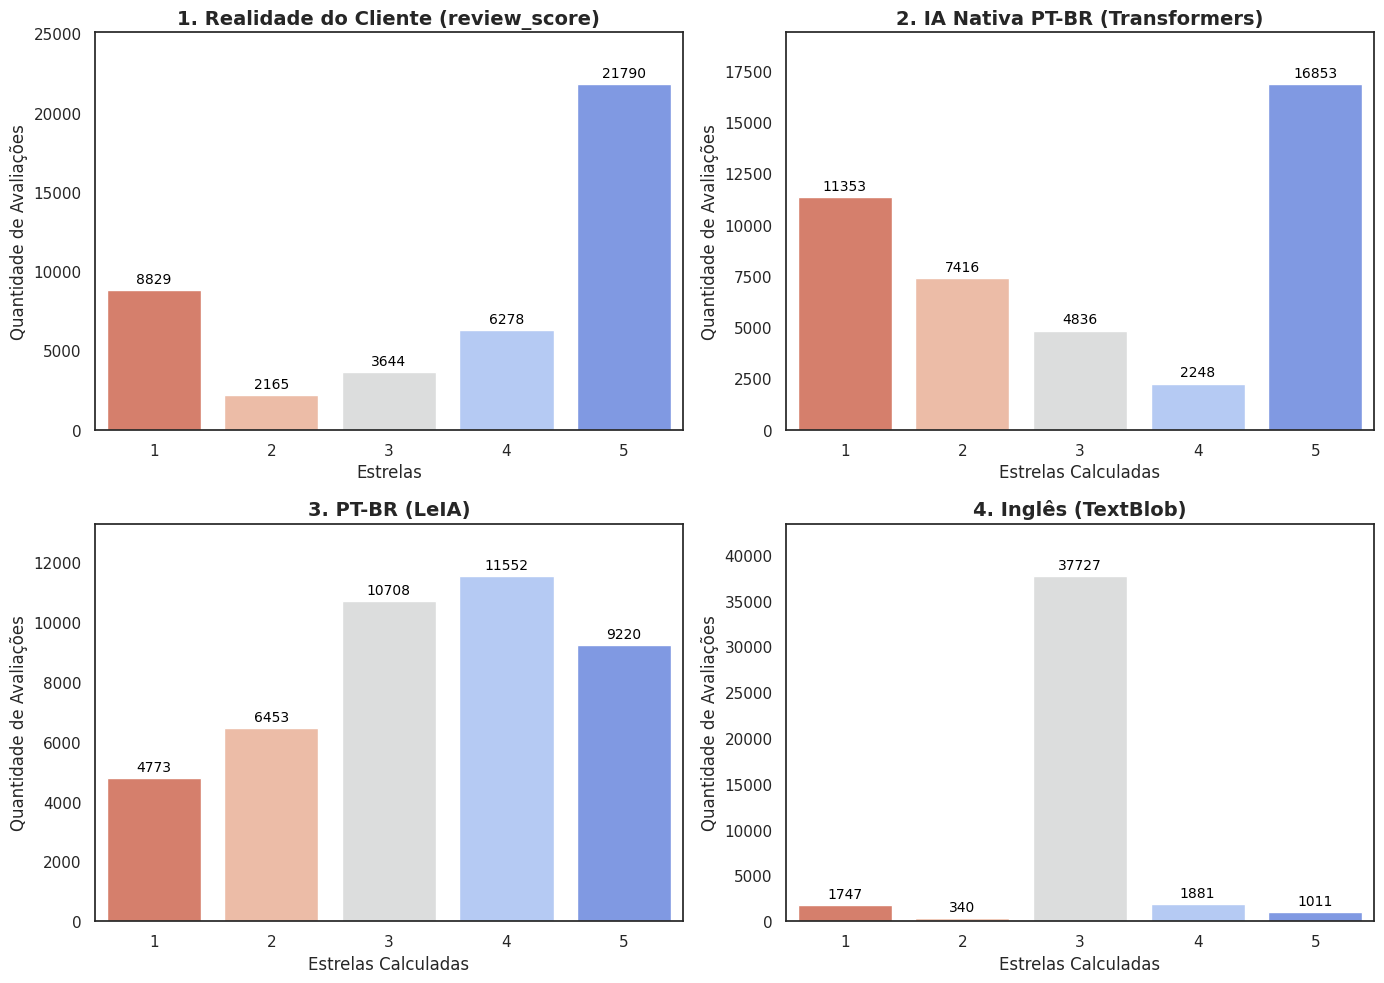

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARREGAMENTO DOS ARQUIVOS
# ==========================================
# Assumimos que o 'df' original já está carregado na memória.
# Vamos carregar os 3 arquivos gerados pelos modelos:
caminho_trans = '/content/df_pronto_regressao_transformers/Transformers_Resultados.parquet'
caminho_leia = '/content/df_pronto_regressao_vader-leIA/LeIA_Resultados.parquet'
caminho_textblob = '/content/df_pronto_regressao_textblob/TextBlob_Resultados.parquet'

df_trans = pd.read_parquet(caminho_trans)
df_leia = pd.read_parquet(caminho_leia)
df_textblob = pd.read_parquet(caminho_textblob)

# ==========================================
# 2. CONFIGURAÇÃO DO PAINEL DE GRÁFICOS
# ==========================================
# Cria uma figura com 4 espaços (2 linhas, 2 colunas)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_theme(style="whitegrid")

# Define a ordem exata das estrelas no Eixo X (1 a 5)
ordem_estrelas = [1, 2, 3, 4, 5]
paleta = "coolwarm_r"  # Vermelho para 1, Azul para 5

# ==========================================
# 3. PLOTANDO OS 4 GRÁFICOS
# ==========================================

# Gráfico 1: Realidade (Cliente)
sns.countplot(data=df_tratado, x='review_score', order=ordem_estrelas, palette=paleta, ax=axes[0, 0])
axes[0, 0].set_title('1. Realidade do Cliente (review_score)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Estrelas')
axes[0, 0].set_ylabel('Quantidade de Avaliações')

# Gráfico 2: Transformers
sns.countplot(data=df_trans, x='nota_mensagem', order=ordem_estrelas, palette=paleta, ax=axes[0, 1])
axes[0, 1].set_title('2. IA Nativa PT-BR (Transformers)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Estrelas Calculadas')
axes[0, 1].set_ylabel('Quantidade de Avaliações')

# Gráfico 3: VADER (LeIA)
sns.countplot(data=df_leia, x='nota_mensagem', order=ordem_estrelas, palette=paleta, ax=axes[1, 0])
axes[1, 0].set_title('3. PT-BR (LeIA)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Estrelas Calculadas')
axes[1, 0].set_ylabel('Quantidade de Avaliações')

# Gráfico 4: TextBlob (Tradução)
sns.countplot(data=df_textblob, x='nota_mensagem', order=ordem_estrelas, palette=paleta, ax=axes[1, 1])
axes[1, 1].set_title('4. Inglês (TextBlob)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Estrelas Calculadas')
axes[1, 1].set_ylabel('Quantidade de Avaliações')

# ==========================================
# 4. ADICIONANDO OS NÚMEROS NO TOPO DAS BARRAS
# ==========================================
for ax in axes.flatten():
    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f', padding=3, color='black', fontsize=10)

    # Ajusta o limite do Eixo Y para os números não cortarem no topo
    ax.margins(y=0.15)

# Ajusta o espaçamento geral para ficar bonito e limpo
plt.tight_layout()
plt.show()